# Aula 7: X do SARIMAX, Auto ARIMA

- Revisão:
    - AR, MA, I e S
    - X e atenções necessárias

- O X da questão:
    - Regressão Linear
    - Combinação simples de um ARIMA com a Regressão
    - Função de Correlação Cruzada e utilização de lags nas inputs
    - Análise de Cenários
    - Variáveis de evento
    - Outliers


In [15]:
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
from funcoes import all_ac, plot_forecast, teste_estacionariedade, diagnostico, compara_previsoes, correlacao_cruzada, compara_estatisticas
plt.rcParams["figure.figsize"] = [12, 5]
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [16]:
df = pd.read_csv('/Users/danielferreira/Documents/git/classes/ASN/Séries Temporais/dados/clicks_original.csv')
df.index = pd.to_datetime(df['date'])
df = df.drop(['date'], axis=1)
df.index.freq = 'D'
df = df[:-1] # Tirando o último ponto por ser um outlier, vou discutir isso depois
df

/var/folders/f1/tdh3lyp114g78tg5wv2t7g3m0000gn/T/ipykernel_3384/1031137758.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime(df['date'])


,price,location,clicks
date,,,
2008-04-01,43.155647,2,18784
2008-04-02,43.079056,1,24738
2008-04-03,43.842609,2,15209
2008-04-04,43.312376,1,14018
2008-04-05,43.941176,1,11974
...,...,...,...
2008-08-08,43.730836,1,13744
2008-08-09,44.182033,1,6716
2008-08-10,43.608260,1,9523


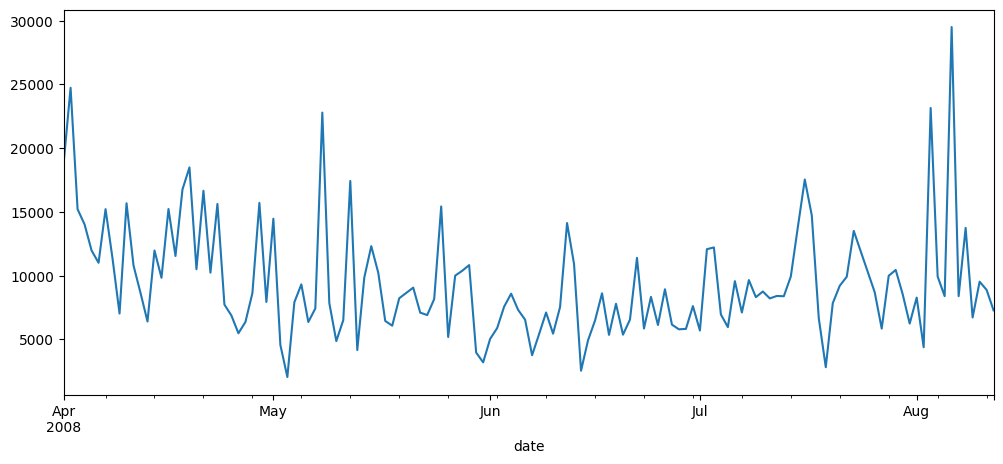

('Não Estacionário', 'Estacionário')

In [17]:
y = df['clicks']
y.plot()
plt.show()
teste_estacionariedade(y)

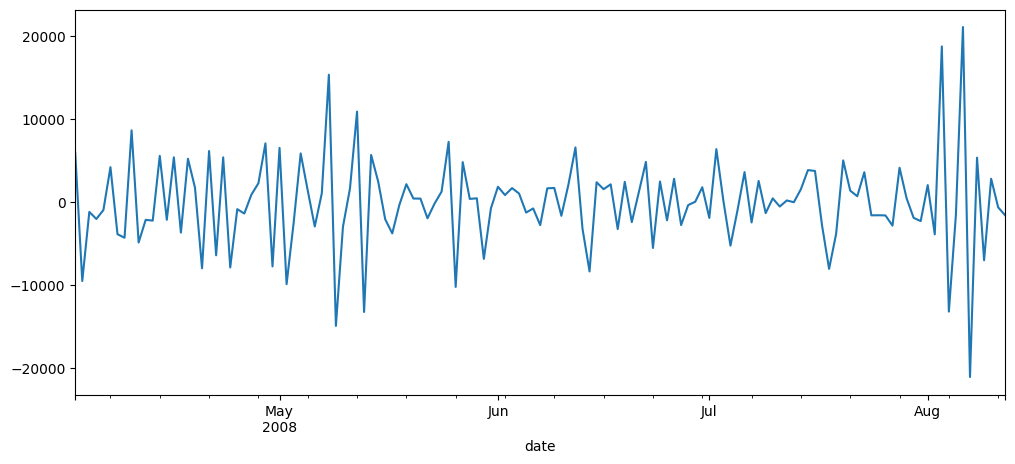

('Estacionário', 'Estacionário')

In [18]:
primeira_ordem = y.diff().dropna()
primeira_ordem.plot()
plt.show()
teste_estacionariedade(primeira_ordem)

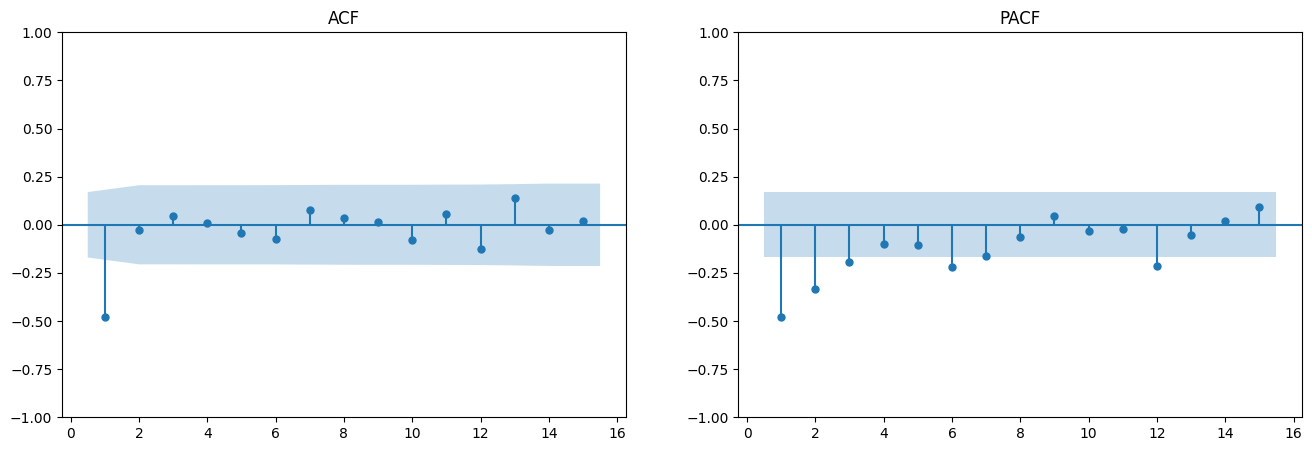

In [19]:
all_ac(primeira_ordem)

                               SARIMAX Results                                
Dep. Variable:                 clicks   No. Observations:                  134
Model:               SARIMAX(0, 1, 1)   Log Likelihood               -1301.175
Date:                Tue, 18 Mar 2025   AIC                           2606.350
Time:                        15:57:25   BIC                           2612.131
Sample:                    04-01-2008   HQIC                          2608.699
                         - 08-12-2008                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.9070      0.041    -22.370      0.000      -0.986      -0.828
sigma2      2.017e+07   9.42e-11   2.14e+17      0.000    2.02e+07    2.02e+07
Ljung-Box (L1) (Q):                   0.07   Jarque-

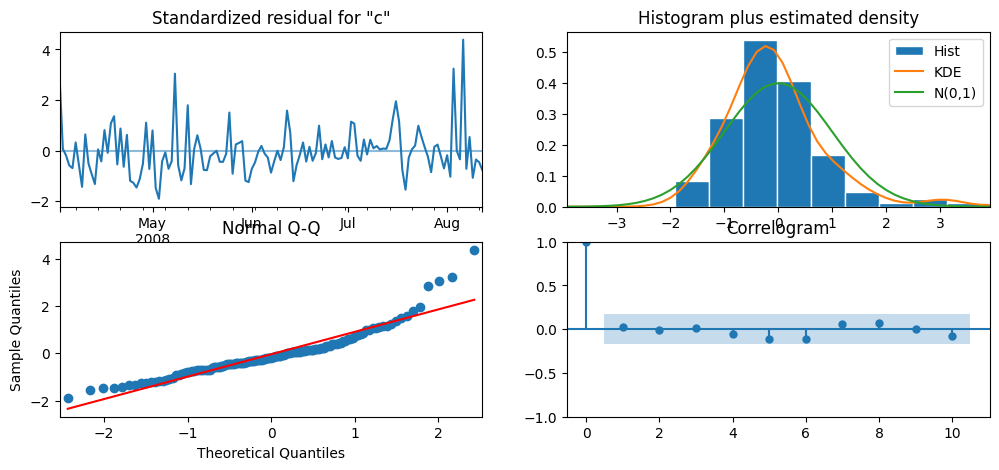

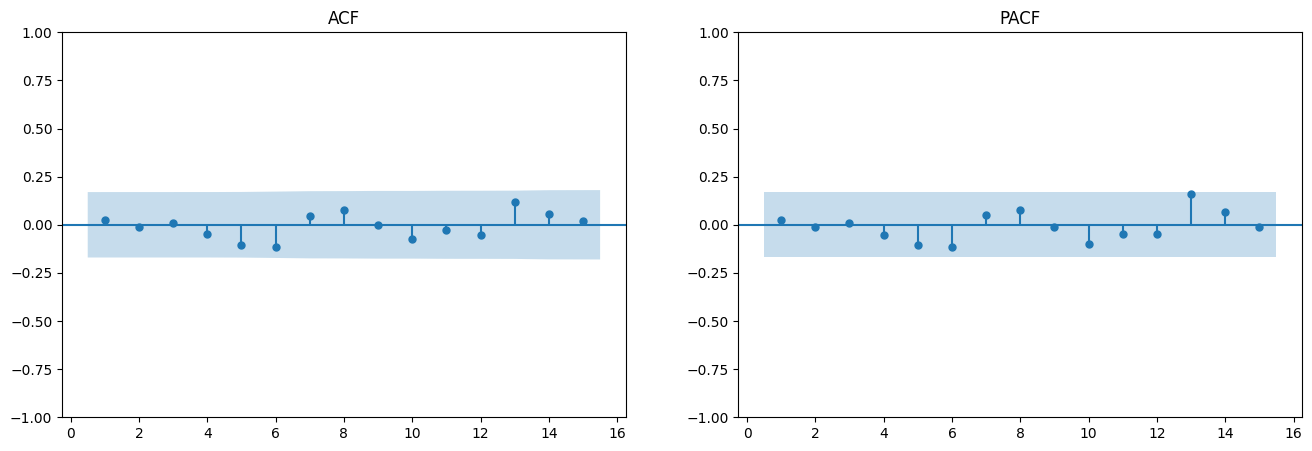

In [20]:
model1 = SARIMAX(y, order=(0,1,1)).fit(disp=False)
diagnostico(model1)

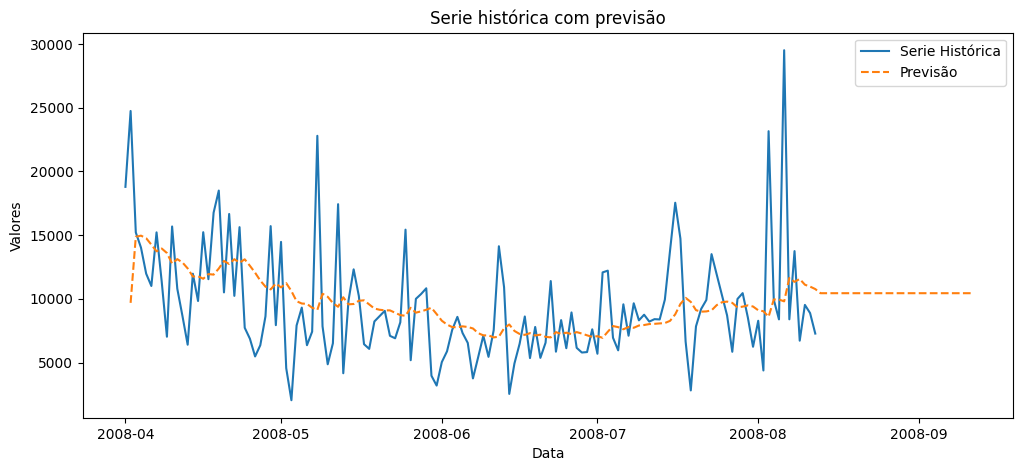

BIC = 2612 - Training RMSE = 4601


In [21]:
forecast = model1.forecast(30)
previsao = model1.fittedvalues[1:]
previsao1 = pd.concat([previsao, forecast])
rmse = np.sqrt(np.mean(model1.resid**2))
bic = model1.bic
plot_forecast(y,previsao1)
print(f'BIC = {round(bic)} - Training RMSE = {round(rmse)}')

Ok, BIC = 2612, RMSE = 4601 não sei se é bom, mas vamos explorar como melhorar o modelo. Talvez com uma Regressão:

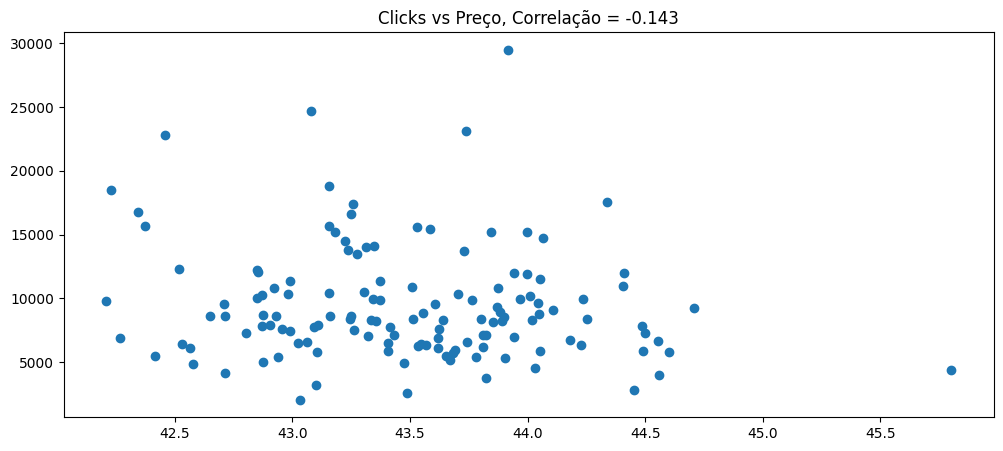

In [22]:
x = df['price']
correl = round(y.corr(x),3)
plt.scatter(x, y)
plt.title(f'Clicks vs Preço, Correlação = {correl}')
plt.show()

In [23]:
import statsmodels.api as sm
model2 = sm.OLS(y, sm.add_constant(x)).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                 clicks   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     2.759
Date:                Tue, 18 Mar 2025   Prob (F-statistic):             0.0991
Time:                        15:57:25   Log-Likelihood:                -1315.2
No. Observations:                 134   AIC:                             2634.
Df Residuals:                     132   BIC:                             2640.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       5.549e+04   2.77e+04      2.003      0.0

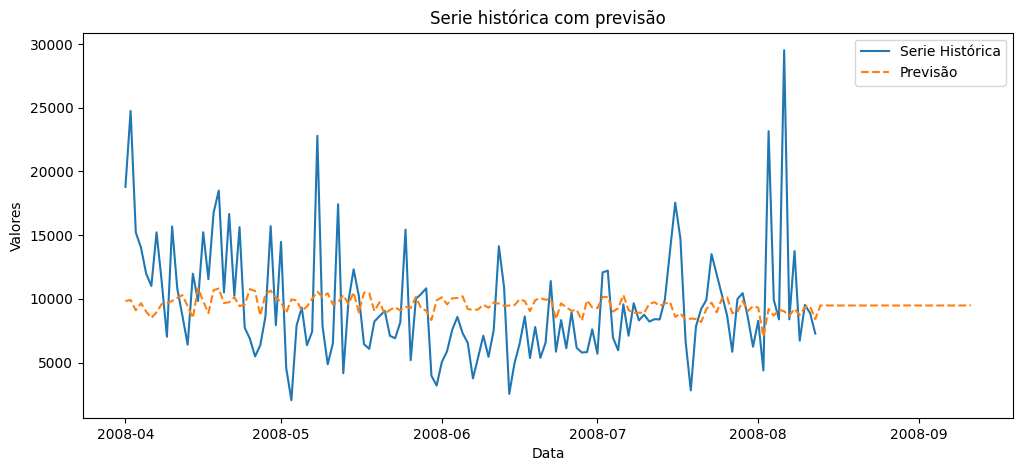

BIC = 2640 - Training ASE = 4429


In [24]:
ultima = df.index[-1]
primeiro_for = ultima + pd.Timedelta(days=1)
for_range = pd.date_range(start=primeiro_for, periods=30)
media_preco = df['price'].mean()
preco_futuro = pd.Series([media_preco]*30, index = for_range)
preco_futuro_df = pd.DataFrame({'const': 1, 'price': preco_futuro})
forecast = model2.predict(preco_futuro_df)
previsao = model2.fittedvalues
previsao2 = pd.concat([previsao, forecast])
rmse = np.sqrt(np.mean(model2.resid**2))
bic = model2.bic
plot_forecast(y, previsao2)
print(f'BIC = {round(bic)} - Training ASE = {round(rmse)}')

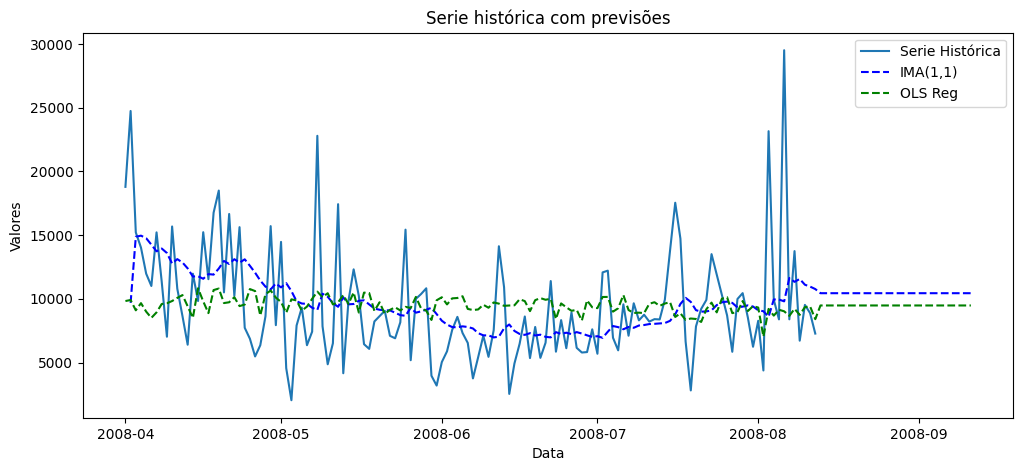

In [25]:
compara_previsoes(y,[previsao1,previsao2], ['IMA(1,1)','OLS Reg'])

Como combinar os dois modelos?

                               SARIMAX Results                                
Dep. Variable:                 clicks   No. Observations:                  134
Model:               SARIMAX(1, 1, 1)   Log Likelihood               -1303.587
Date:                Tue, 18 Mar 2025   AIC                           2615.174
Time:                        15:57:26   BIC                           2626.735
Sample:                    04-01-2008   HQIC                          2619.872
                         - 08-12-2008                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
price        -95.7440    118.044     -0.811      0.417    -327.107     135.619
ar.L1          0.2240      0.084      2.659      0.008       0.059       0.389
ma.L1         -1.0000      0.078    -12.787      0.0

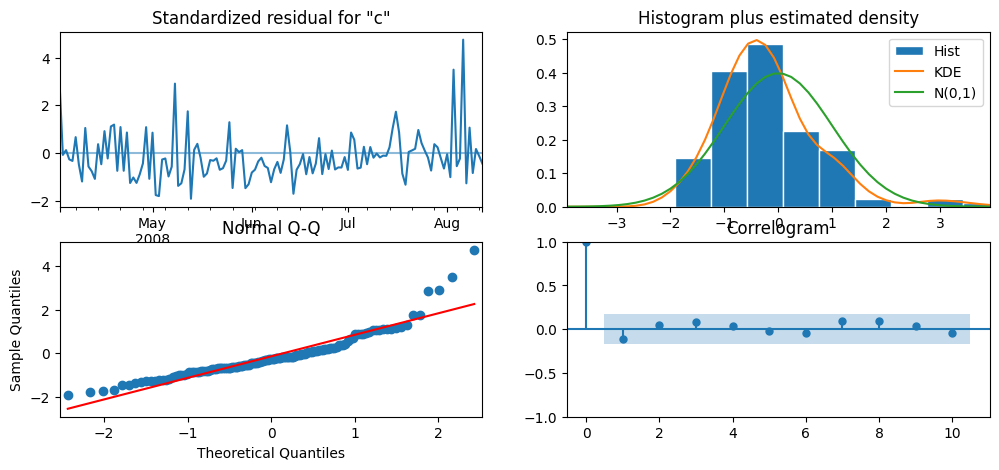

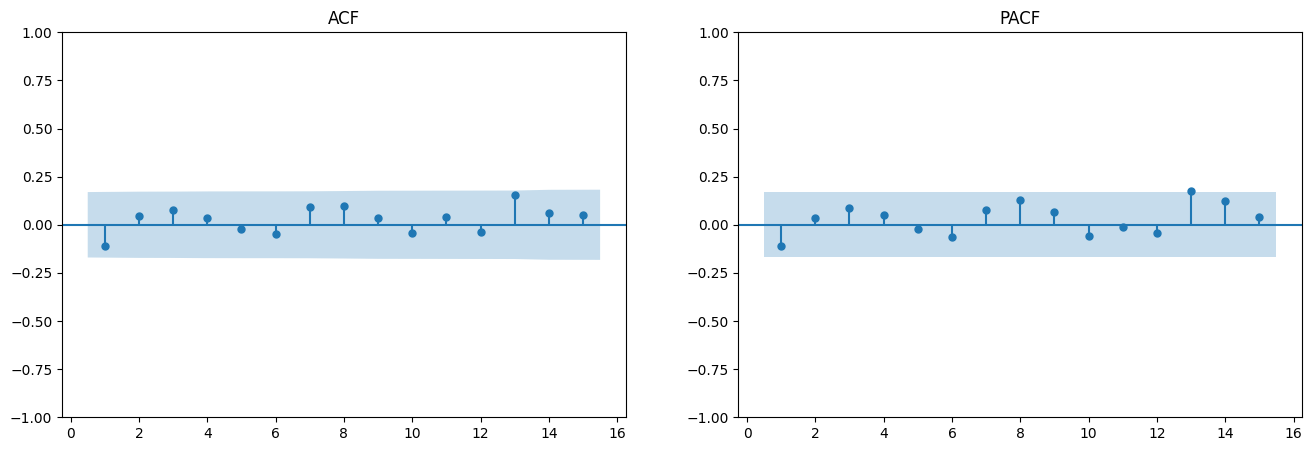

In [26]:
model3 = SARIMAX(y, order=(1,1,1), exog=x).fit(disp=False)
diagnostico(model3)

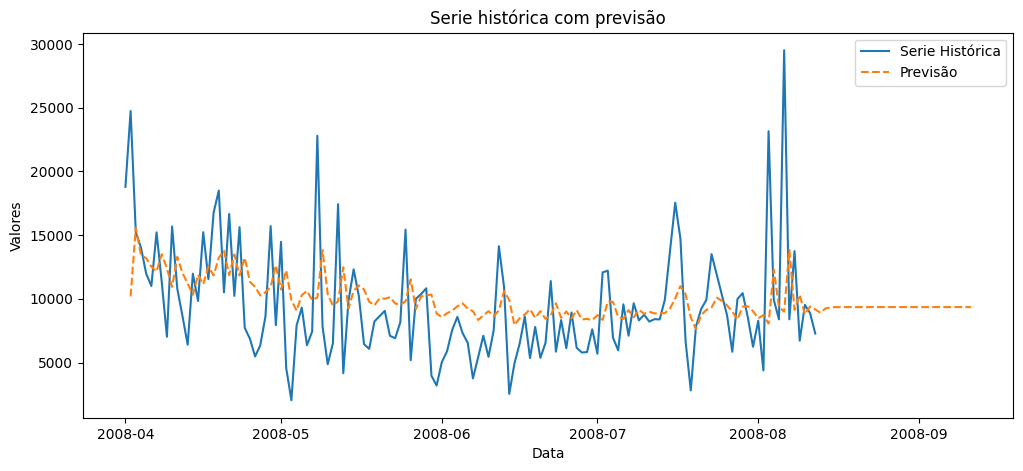

BIC = 2627 - Training RMSE = 4810


In [27]:
forecast = model3.get_forecast(steps=30, exog=preco_futuro).predicted_mean
previsao = model3.fittedvalues[1:]
previsao3 = pd.concat([previsao, forecast])
rmse = np.sqrt(np.mean(model3.resid**2))
bic = model3.bic
plot_forecast(y,previsao3)
print(f'BIC = {round(bic)} - Training RMSE = {round(rmse)}')

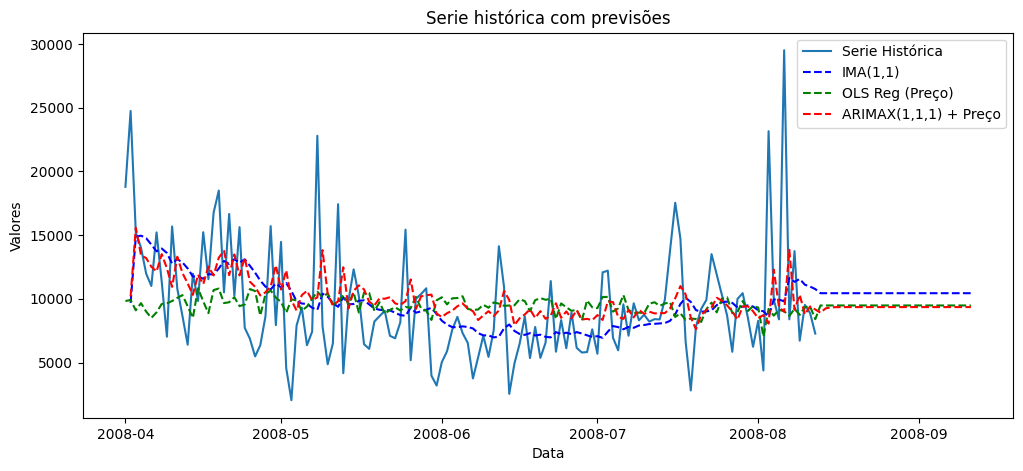

In [28]:
compara_previsoes(y, [previsao1,previsao2,previsao3],  ['IMA(1,1)','OLS Reg (Preço)', 'ARIMAX(1,1,1) + Preço'])

In [29]:
compara_estatisticas( [model1,model2,model3], ['IMA(1,1)','OLS Reg Preço', 'ARIMAX(1,1,1) + Preço'])

BIC = 2612 -- AIC = 2606 --  RMSE = 4601 - IMA(1,1)
BIC = 2640 -- AIC = 2634 --  RMSE = 4429 - OLS Reg Preço
BIC = 2627 -- AIC = 2615 --  RMSE = 4810 - ARIMAX(1,1,1) + Preço


## Análise de Cenários


/Users/danielferreira/miniconda3/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


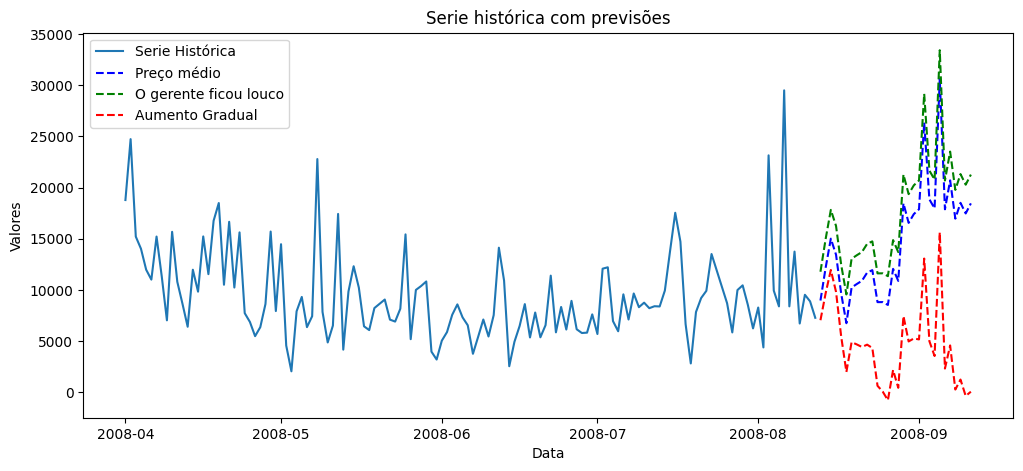

In [44]:
model = SARIMAX(y,order=(1,1,1), seasonal_order=(1,1,1,30), exog=x).fit(disp=False)
passos = 30
preco_medio = df['price'].mean()
preco_medio_f = [preco_medio]*passos
preco_min_f = [42]*passos
aumento_gradual = (df['price'].iloc[-1]) + np.arange(0, 30 * 0.3, 0.3)

cenario1 = model.get_forecast(steps=passos, exog=preco_medio_f).predicted_mean
cenario2 = model.get_forecast(steps=passos, exog=preco_min_f).predicted_mean
cenario3 = model.get_forecast(steps=passos, exog=aumento_gradual).predicted_mean

compara_previsoes(y,[cenario1,cenario2,cenario3], ['Preço médio', 'O gerente ficou louco', 'Aumento Gradual'])

In [31]:
df['price'].iloc[-1]

np.float64(44.50046948)

In [34]:
aumento_gradual = (df['price'].iloc[-1]) + np.arange(0, 30 * 0.1, 0.1)

In [35]:
aumento_gradual

array([44.50046948, 44.60046948, 44.70046948, 44.80046948, 44.90046948,
       45.00046948, 45.10046948, 45.20046948, 45.30046948, 45.40046948,
       45.50046948, 45.60046948, 45.70046948, 45.80046948, 45.90046948,
       46.00046948, 46.10046948, 46.20046948, 46.30046948, 46.40046948,
       46.50046948, 46.60046948, 46.70046948, 46.80046948, 46.90046948,
       47.00046948, 47.10046948, 47.20046948, 47.30046948, 47.40046948])

Vamos tentar melhorar esse ARIMAX.

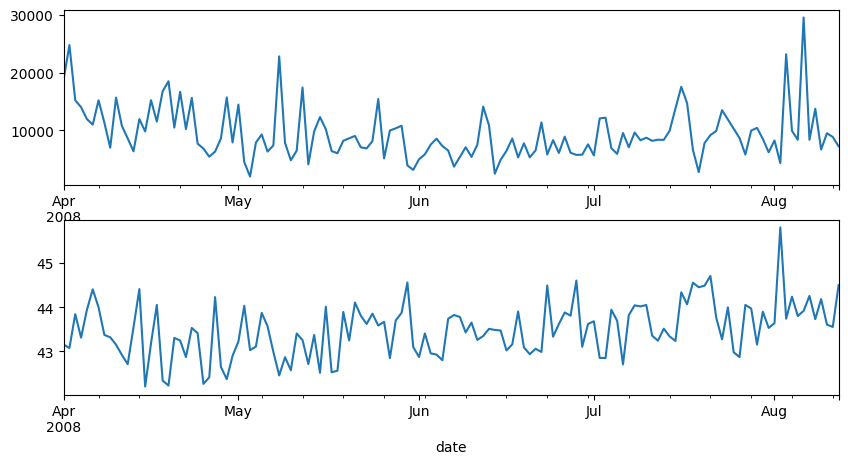

In [31]:
fig, ax = plt.subplots(2, 1, figsize=(10, 5))
y.plot(ax=ax[0])
x.plot(ax=ax[1])
plt.show()

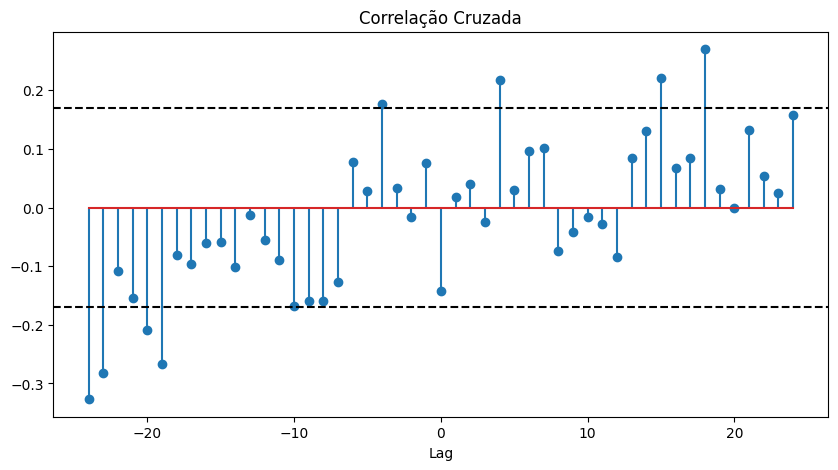

In [18]:
correlacao_cruzada(y,x)